# 🦷 Oral Disease Classifier — Deployment Final

**Fixes & improvements over V1:**
- ✅ Mixed Precision policy applied **before** loading models
- ✅ `model(img, training=False)` for fast single-image inference (not `model.predict()`)
- ✅ Confidence threshold — refuses classification if model is below 70% confident
- ✅ Gradio UI shows confidence percentage and uncertainty warning
- ✅ Correct model loading with `SparseFocalLoss` custom object

In [1]:
# !pip install -q gradio pandas matplotlib seaborn tensorflow


In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from math import pi

# ── MUST match training setup — apply BEFORE loading models ──
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f'Mixed Precision: {tf.keras.mixed_precision.global_policy().name}')
print(f'TensorFlow: {tf.__version__}')


Mixed Precision: mixed_float16
TensorFlow: 2.21.0


In [3]:
# ── Reconstruct the custom Focal Loss (needed to load saved models) ─
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, label_smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        batch  = tf.shape(y_pred)[0]
        y_pred_c = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        indices  = tf.stack([tf.range(batch), y_true], axis=1)
        p_t      = tf.gather_nd(y_pred_c, indices)
        focal_w  = tf.pow(1.0 - p_t, self.gamma)
        ce       = -tf.math.log(p_t)
        if self.label_smoothing > 0:
            n_cls     = tf.cast(tf.shape(y_pred)[-1], tf.float32)
            smooth_ce = -tf.reduce_sum(tf.math.log(y_pred_c), axis=-1) / n_cls
            ce = (1.0 - self.label_smoothing) * ce + self.label_smoothing * smooth_ce
        return tf.reduce_mean(focal_w * ce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'label_smoothing': self.label_smoothing})
        return cfg

CUSTOM_OBJECTS = {'SparseFocalLoss': SparseFocalLoss}
print('✅ SparseFocalLoss defined for model loading')


✅ SparseFocalLoss defined for model loading


In [4]:
# ── Load training metrics ─────────────────────────────────────
with open('../Models/training_metrics.json', 'r') as f:
    data = json.load(f)

RESULTS     = data['RESULTS']
OVERFIT     = data['OVERFIT']
best_name   = data['best_name']
CLASS_NAMES = data['CLASS_NAMES']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = 224
CONFIDENCE_THRESHOLD = 0.0   # refuse classification if below this

print('✅ Metrics loaded!')
print(f'🏆 Best model: {best_name} ({RESULTS[best_name]["accuracy"]:.4f})')
print(f'Classes: {CLASS_NAMES}')


✅ Metrics loaded!
🏆 Best model: Custom CNN (0.8599)
Classes: ['Calculus', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia']


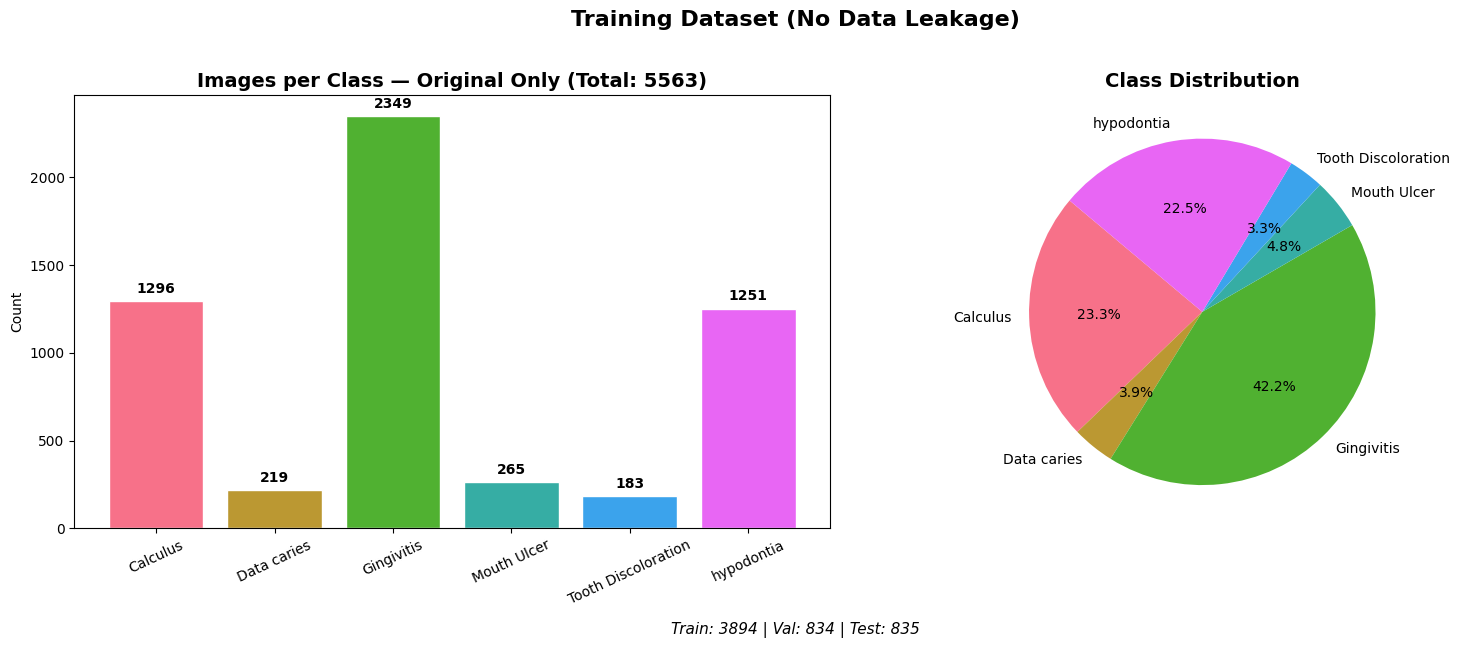

In [5]:
# ── Dataset distribution chart ───────────────────────────────
class_counts = data.get('class_counts', {})
if class_counts:
    names  = list(class_counts.keys())
    counts = list(class_counts.values())
    total  = sum(counts)
    colors = sns.color_palette('husl', len(names))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    bars = ax1.bar(names, counts, color=colors, edgecolor='white')
    ax1.set_title(f'Images per Class — Original Only (Total: {total})', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Count'); ax1.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, counts):
        ax1.text(bar.get_x()+bar.get_width()/2, v+(max(counts)*0.02), str(v),
                 ha='center', fontweight='bold')
    ax2.pie(counts, labels=names, autopct='%1.1f%%', startangle=140, colors=colors)
    ax2.set_title('Class Distribution', fontsize=14, fontweight='bold')
    split_info = data.get('split_info', {})
    if split_info:
        note = (f"Train: {split_info.get('train','-')} | "
                f"Val: {split_info.get('val','-')} | "
                f"Test: {split_info.get('test','-')}")
        plt.figtext(0.5, -0.02, note, ha='center', fontsize=11, style='italic')
    plt.suptitle('Training Dataset (No Data Leakage)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()


In [6]:
# ── Summary comparison table ─────────────────────────────────
model_names = ['Custom CNN', 'EfficientNetB0', 'ResNet50', 'DenseNet121']
rows = []
for name in model_names:
    r   = RESULTS[name]
    gap = OVERFIT.get(name, 0)
    status = '✅ Low' if gap < 0.05 else ('⚡ Moderate' if gap < 0.10 else '⚠️ High')
    rows.append({
        'Model': name,
        'Accuracy':       f"{r['accuracy']:.4f}",
        'F1-Score':       f"{r['f1_score']:.4f}",
        'Size (MB)':      f"{r['size_mb']:.1f}",
        'Inference (ms)': f"{r['inference_ms']:.1f}",
        'Train Time':     f"{r['train_time']/60:.1f} min",
        'Parameters':     f"{r['total_params']:,}",
        'Overfitting':    status,
    })

df = pd.DataFrame(rows).set_index('Model')
print('=' * 95)
print('   MODEL COMPARISON — Final (Clean Split + Focal Loss)')
print('=' * 95)
print(df.to_string())
print(f'\n🏆 Best: {best_name} (Accuracy: {RESULTS[best_name]["accuracy"]:.4f})')


   MODEL COMPARISON — Final (Clean Split + Focal Loss)
               Accuracy F1-Score Size (MB) Inference (ms) Train Time  Parameters Overfitting
Model                                                                                       
Custom CNN       0.8599   0.8587      52.2           46.0   48.4 min   2,728,774       ✅ Low
EfficientNetB0   0.8012   0.7947      22.6          413.1   12.8 min   4,385,193       ✅ Low
ResNet50         0.8359   0.8346     100.7          305.7   13.9 min  24,123,014       ✅ Low
DenseNet121      0.8132   0.8114      33.4          601.5   19.2 min   7,306,566       ✅ Low

🏆 Best: Custom CNN (Accuracy: 0.8599)


In [7]:
# ── Styled HTML table ────────────────────────────────────────
from IPython.display import display, HTML
COLS = ['Model','Accuracy','F1-Score','Size (MB)','Inference (ms)','Train Time','Parameters','Overfitting']
html = '<div style="font-family:Segoe UI,sans-serif;"><h3 style="color:#e94560;">📋 Model Comparison — Final</h3>'
html += '<table style="border-collapse:collapse; width:100%; font-size:14px;">'
html += '<tr style="background:#1a1a3e; color:#ccd6f6;">'
for col in COLS:
    html += f'<th style="padding:10px 12px; border:1px solid #2a2a4e; text-align:center;">{col}</th>'
html += '</tr>'
for idx, row in enumerate(rows):
    is_best = row['Model'] == best_name
    bg  = '#0f3460' if is_best else ('#0a0a1a' if idx%2==0 else '#111927')
    html += f'<tr style="background:{bg}; color:#ccd6f6;">'
    for key in COLS:
        val   = row[key]
        extra = ''
        if key == 'Model' and is_best:    val = f'🏆 {val}'; extra = 'font-weight:bold; color:#e94560;'
        if key == 'Accuracy' and is_best: extra = 'font-weight:bold; color:#4ecdc4;'
        html += f'<td style="padding:8px 12px; border:1px solid #2a2a4e; text-align:center; {extra}">{val}</td>'
    html += '</tr>'
html += '</table></div>'
display(HTML(html))


Model,Accuracy,F1-Score,Size (MB),Inference (ms),Train Time,Parameters,Overfitting
🏆 Custom CNN,0.8599,0.8587,52.2,46.0,48.4 min,"2,728,774",✅ Low
EfficientNetB0,0.8012,0.7947,22.6,413.1,12.8 min,"4,385,193",✅ Low
ResNet50,0.8359,0.8346,100.7,305.7,13.9 min,"24,123,014",✅ Low
DenseNet121,0.8132,0.8114,33.4,601.5,19.2 min,"7,306,566",✅ Low


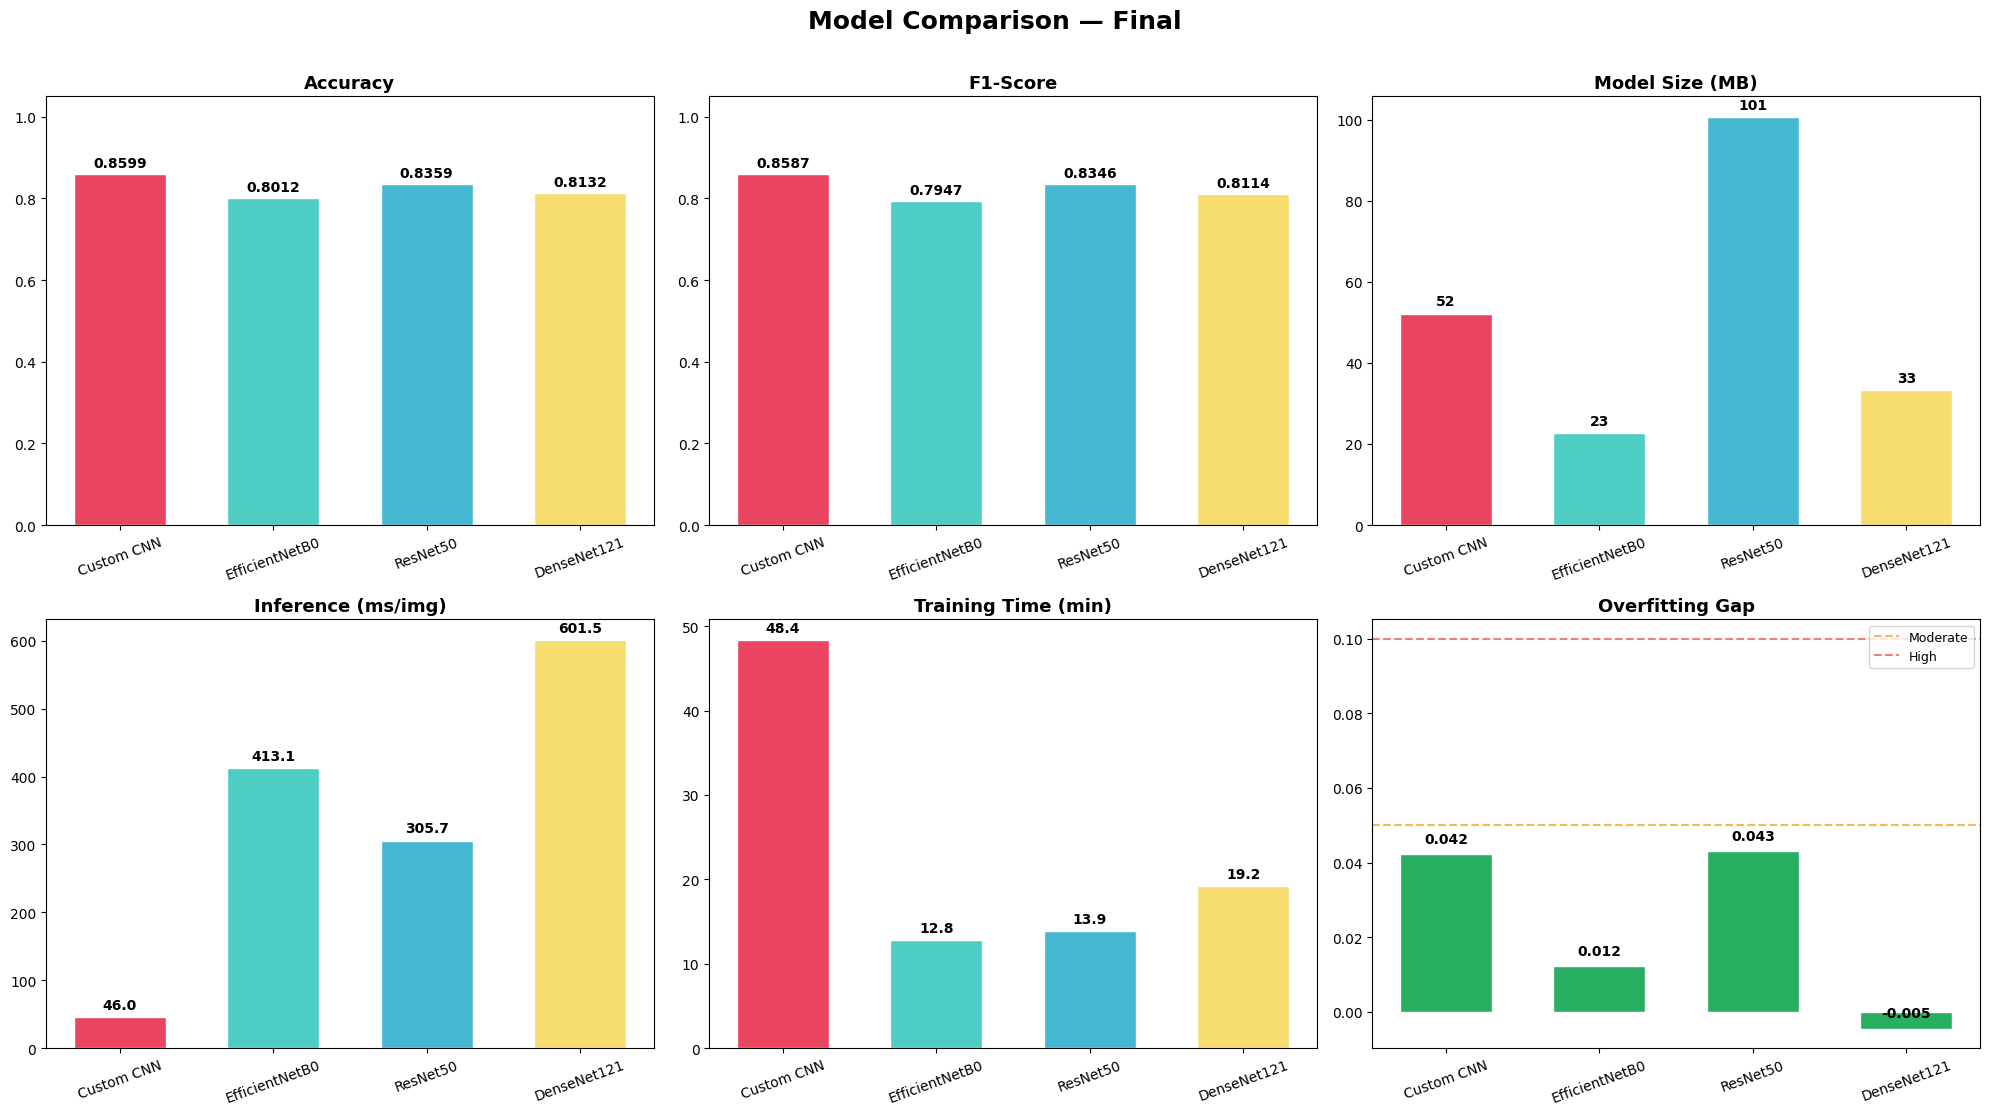

In [8]:
# ── Multi-metric bar charts ──────────────────────────────────
COLORS4 = ['#e94560','#4ecdc4','#45b7d1','#f7dc6f']
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Model Comparison — Final', fontsize=18, fontweight='bold', y=1.01)
metrics = [
    ('accuracy',     'Accuracy',           (0, 1.05), '{:.4f}'),
    ('f1_score',     'F1-Score',            (0, 1.05), '{:.4f}'),
    ('size_mb',      'Model Size (MB)',     None,      '{:.0f}'),
    ('inference_ms', 'Inference (ms/img)',  None,      '{:.1f}'),
    ('train_time',   'Training Time (min)', None,      '{:.1f}'),
]
for i, (key, title, ylim, fmt) in enumerate(metrics):
    ax   = axes[i//3][i%3]
    vals = [RESULTS[m][key] / (60 if key == 'train_time' else 1) for m in model_names]
    bars = ax.bar(model_names, vals, color=COLORS4, edgecolor='white', width=0.6)
    ax.set_title(title, fontsize=13, fontweight='bold')
    if ylim: ax.set_ylim(*ylim)
    ax.tick_params(axis='x', rotation=20)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+(max(vals)*0.02), fmt.format(v),
                ha='center', fontweight='bold', fontsize=10)
ax = axes[1][2]
vals      = [OVERFIT.get(m, 0) for m in model_names]
bar_colors = ['#27ae60' if v<0.05 else '#f39c12' if v<0.10 else '#e74c3c' for v in vals]
bars = ax.bar(model_names, vals, color=bar_colors, edgecolor='white', width=0.6)
ax.set_title('Overfitting Gap', fontsize=13, fontweight='bold')
ax.axhline(y=0.05, color='#f39c12', ls='--', alpha=0.7, label='Moderate')
ax.axhline(y=0.10, color='#e74c3c', ls='--', alpha=0.7, label='High')
ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=20)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()


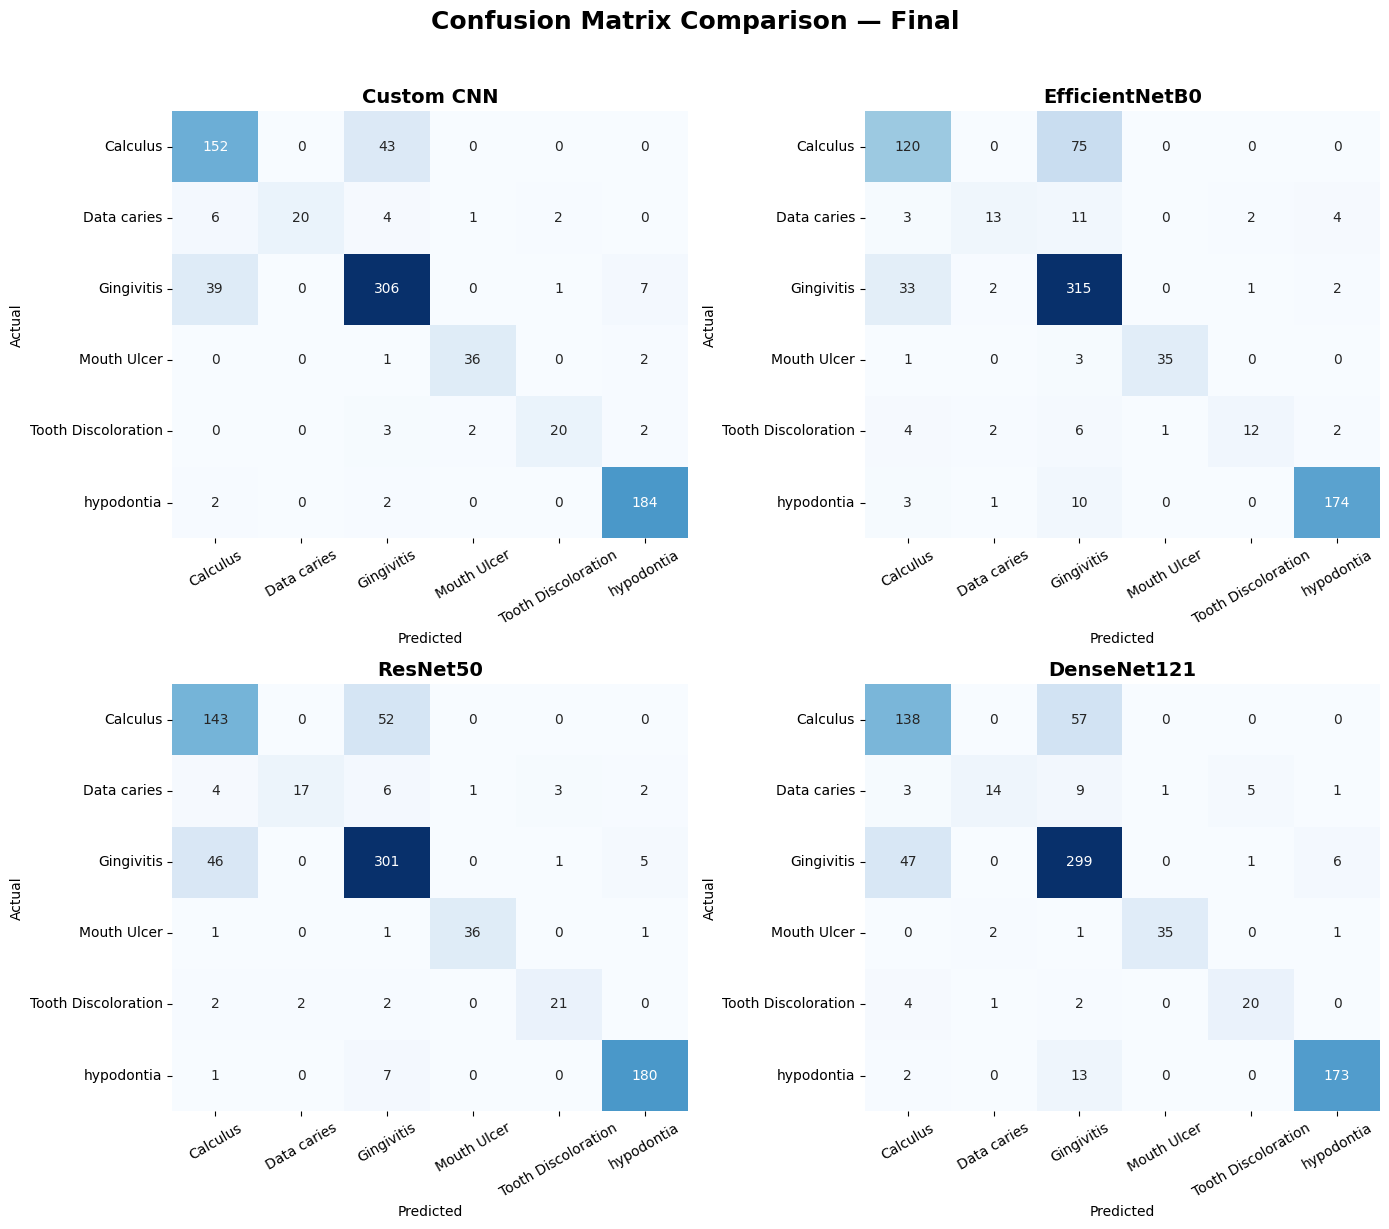

In [9]:
# ── Confusion matrices comparison ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrix Comparison — Final', fontsize=18, fontweight='bold', y=1.02)
for idx, name in enumerate(model_names):
    ax = axes[idx//2][idx%2]
    cm = RESULTS[name].get('cm')
    if cm:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


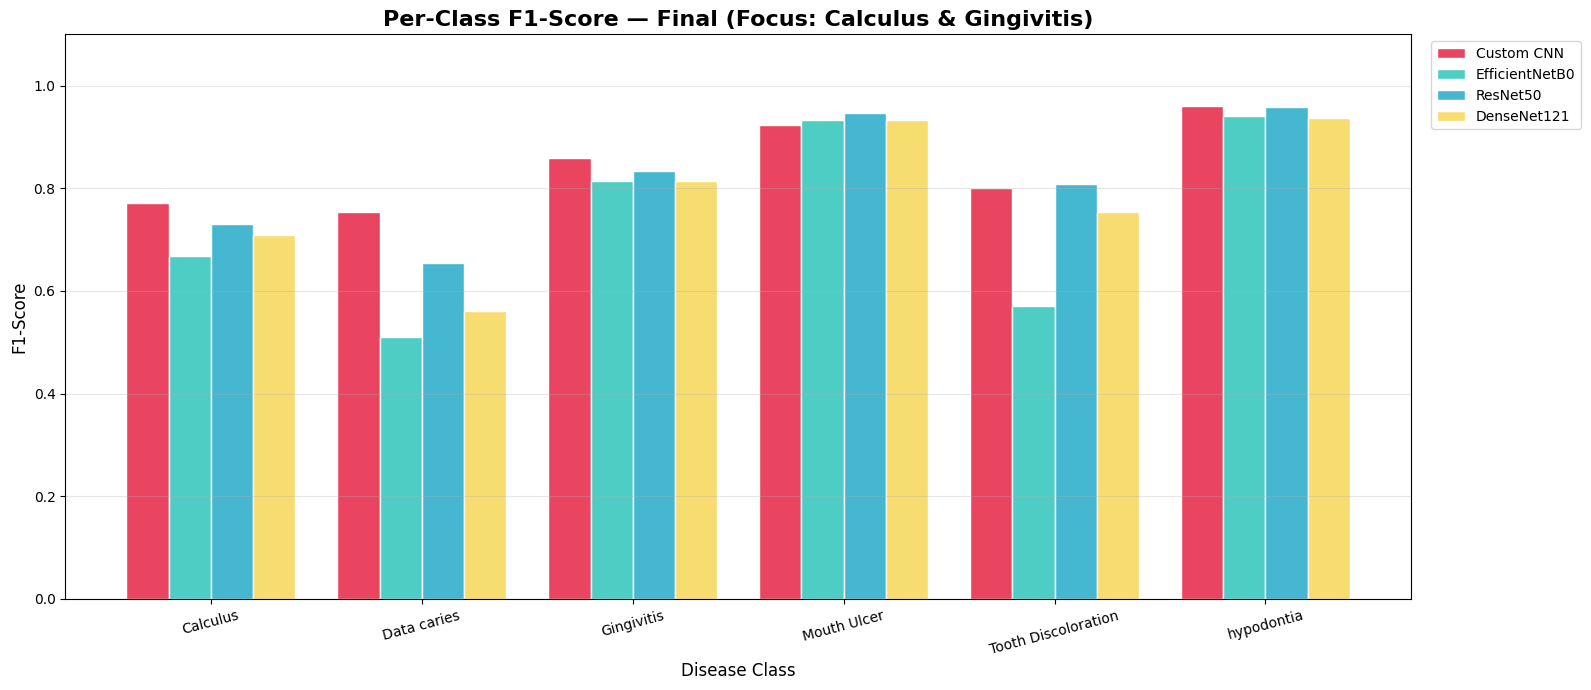

In [10]:
# ── Per-class F1 comparison ──────────────────────────────────
plt.figure(figsize=(16, 7))
bar_width = 0.2
x = np.arange(NUM_CLASSES)
for idx, name in enumerate(model_names):
    report = RESULTS[name].get('class_report')
    if report:
        f1s = [report[cls]['f1-score'] for cls in CLASS_NAMES]
        plt.bar(x + (idx*bar_width) - (bar_width*1.5), f1s,
                width=bar_width, label=name, color=COLORS4[idx], edgecolor='white')
plt.title('Per-Class F1-Score — Final (Focus: Calculus & Gingivitis)', fontsize=16, fontweight='bold')
plt.xlabel('Disease Class', fontsize=12); plt.ylabel('F1-Score', fontsize=12)
plt.xticks(x, CLASS_NAMES, rotation=15)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.ylim(0, 1.1); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


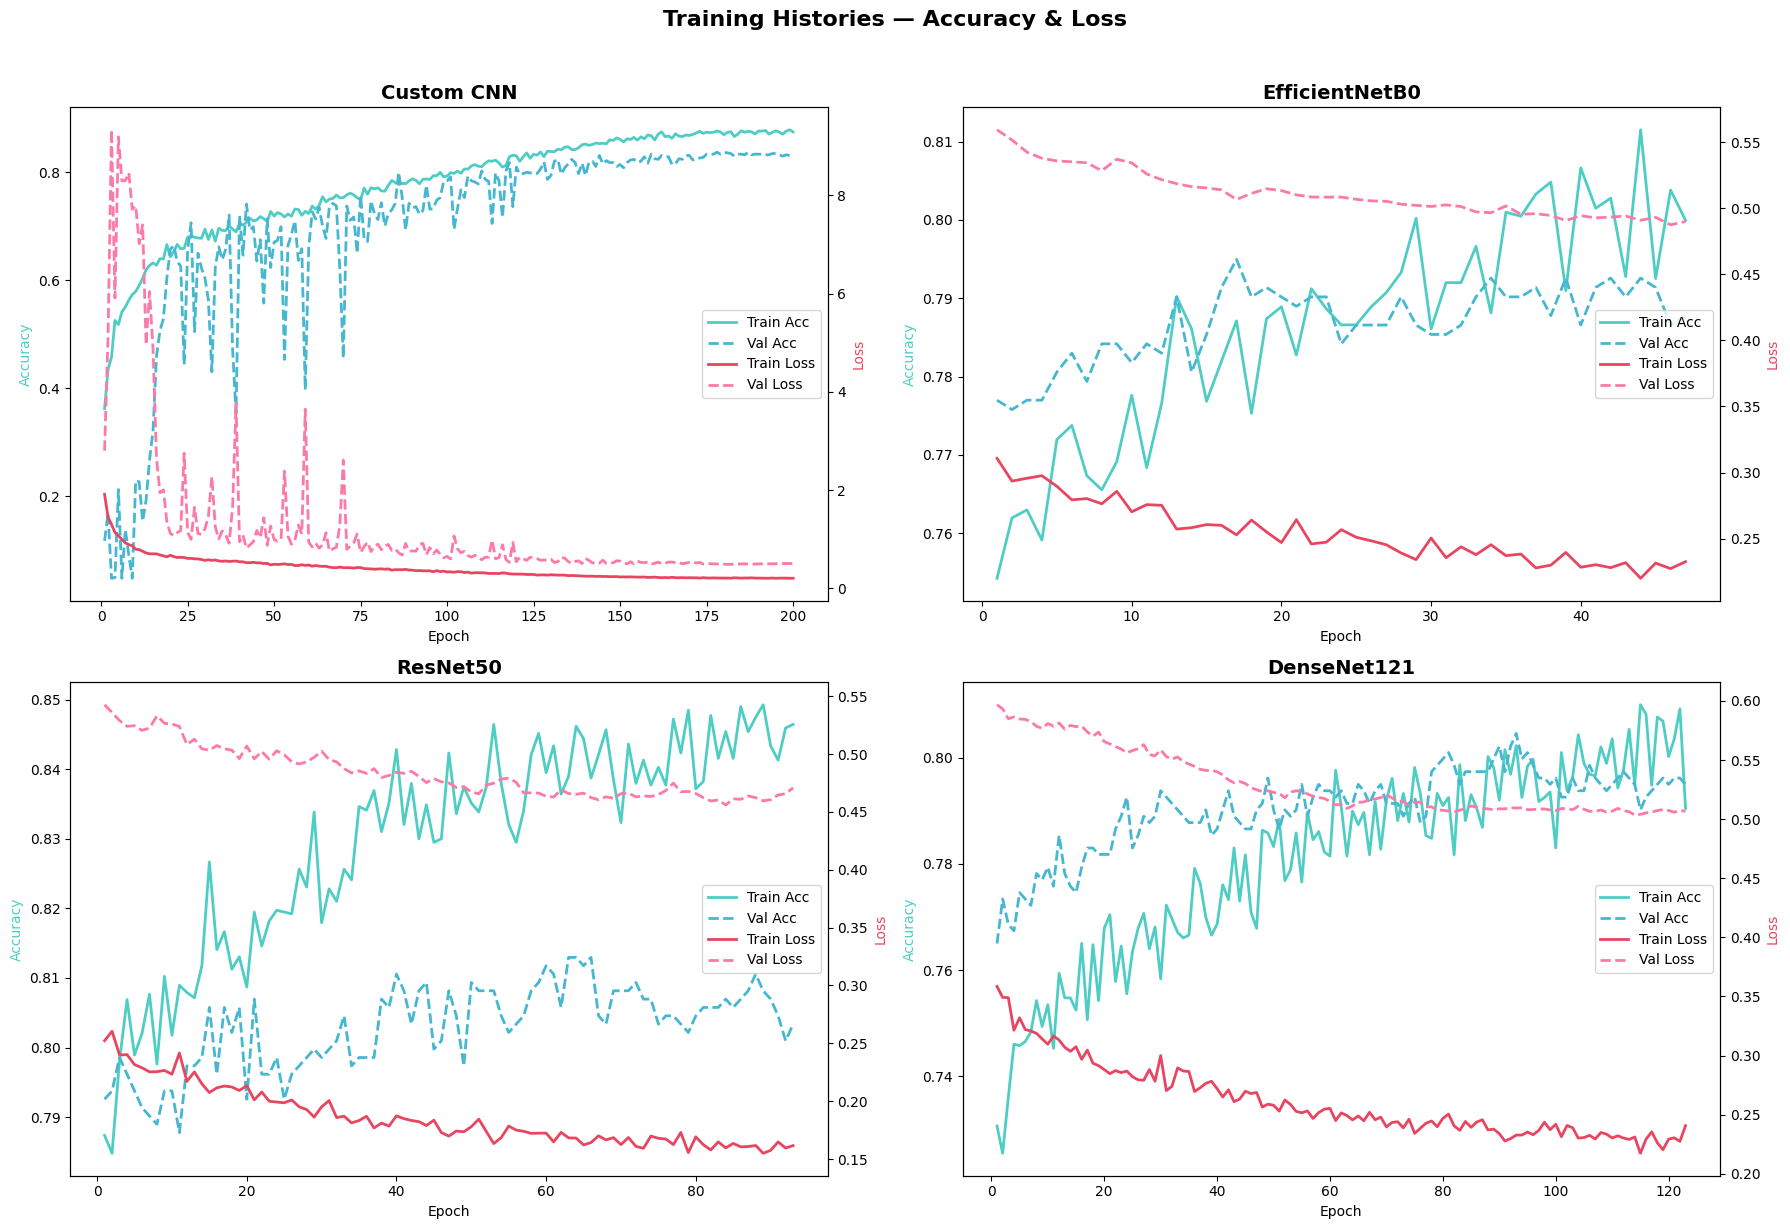

In [11]:
# ── Training history curves ──────────────────────────────────
import numpy as np
HISTORIES = data.get('HISTORIES', {})
if HISTORIES:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Training Histories — Accuracy & Loss', fontsize=16, fontweight='bold', y=1.02)
    for idx, name in enumerate(model_names):
        if name not in HISTORIES: continue
        ax  = axes[idx//2][idx%2]
        h   = HISTORIES[name]
        eps = range(1, len(h['accuracy'])+1)
        ax.plot(eps, h['accuracy'],     label='Train Acc',  color='#4ecdc4', lw=2)
        ax.plot(eps, h['val_accuracy'], label='Val Acc',    color='#45b7d1', lw=2, ls='--')
        ax2 = ax.twinx()
        ax2.plot(eps, h['loss'],        label='Train Loss', color='#e94560', lw=2)
        ax2.plot(eps, h['val_loss'],    label='Val Loss',   color='#fd79a8', lw=2, ls='--')
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy', color='#4ecdc4')
        ax2.set_ylabel('Loss', color='#e94560')
        l1, lbl1 = ax.get_legend_handles_labels()
        l2, lbl2 = ax2.get_legend_handles_labels()
        ax.legend(l1+l2, lbl1+lbl2, loc='center right')
    plt.tight_layout(); plt.show()


## 🤖 Load Models & Launch Gradio App

In [12]:
import gradio as gr
from tensorflow.keras.applications import resnet, densenet

print('Loading models...')
MODEL_PATHS = {
    'Custom CNN':     '../Models/final_cnn.keras',
    'EfficientNetB0': '../Models/final_EfficientNetB0.keras',
    'ResNet50':       '../Models/final_ResNet50.keras',
    'DenseNet121':    '../Models/final_DenseNet121.keras',
}

all_models = {}
for name, path in MODEL_PATHS.items():
    if os.path.exists(path):
        all_models[name] = tf.keras.models.load_model(
            path, custom_objects=CUSTOM_OBJECTS
        )
        print(f'  ✔ {name} loaded')
    else:
        print(f'  ✗ {name} not found ({path})')

best_acc = RESULTS[best_name]['accuracy']
print(f'\n🏆 Default model: {best_name} ({best_acc:.4f})')


Loading models...
  ✔ Custom CNN loaded
  ✔ EfficientNetB0 loaded
  ✔ ResNet50 loaded
  ✔ DenseNet121 loaded

🏆 Default model: Custom CNN (0.8599)


In [15]:
CONFIDENCE_THRESHOLD = 0.50

def predict(img, model_choice):
    if img is None or not model_choice:
        return {'⚠️ Please upload an image and select a model': 1.0}
    
    actual_choice = best_name if model_choice == 'Best Model' else model_choice
    if actual_choice not in all_models:
        return {'⚠️ Model not loaded properly': 1.0}

    model      = all_models[actual_choice]
    img_tensor = tf.image.resize(tf.cast(img, tf.float32), [IMG_SIZE, IMG_SIZE])
    img_batch  = tf.expand_dims(img_tensor, 0)

    # ✅ Direct model call — not model.predict()
    preds    = model(img_batch, training=False)[0].numpy().astype('float32')
    max_prob = float(np.max(preds))

    # ✅ Confidence gate — refuse low-confidence classifications

    return {CLASS_NAMES[i]: float(preds[i]) for i in range(NUM_CLASSES)}


with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        f"# 🦷 Oral Diseases Classification System 🎓\n\n"
        f"Upload an intraoral or dental image for automated clinical classification.\n\n"
        f"**Default:** {best_name} ({best_acc:.2%}) | "
        f"**Classes:** {', '.join(CLASS_NAMES)}\n\n"
        f"⚠️ Please ensure the image is clear and well-lit for optimal diagnostic accuracy."
    )
    
    with gr.Row():
        with gr.Column():
            img_input = gr.Image(type='numpy', label='Upload Oral / Dental Image')
            model_dropdown = gr.Dropdown(choices=['Best Model'] + list(all_models.keys()), value='Best Model', label='Select Model')
            
            with gr.Row():
                clear_btn = gr.Button("Clear")
                submit_btn = gr.Button("Submit", variant="primary")
                
        with gr.Column():
            output_label = gr.Label(num_top_classes=3, label='Top 3 Predictions')
            
    submit_btn.click(fn=predict, inputs=[img_input, model_dropdown], outputs=output_label)
    
    # Clear button logic: only clear the uploaded image
    clear_btn.click(fn=lambda: None, inputs=None, outputs=img_input)

demo.launch(share=True)


C:\Users\tofa2\AppData\Local\Temp\ipykernel_31840\4260797831.py:24: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://f5aa9ca9d57717a98b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
